# Random Forest non-recursive forecast - target ln(OIL_NEXT)

This notebook uses the same DCA-like `build_features()` feature engineering style, but **does not use recursive forecasting**.

Target:

```python
LN_OIL_TARGET = ln(OIL_NEXT)
```

Forecasting behavior:

```text
actual historical oil history -> build_features() -> predict ln(OIL_NEXT) -> convert back to OIL
```

Important difference from recursive forecasting:

- This notebook **does not append predicted oil back into history**.
- Test-period predictions are made only from feature rows built from actual historical data.
- A one-step future prediction after the last actual data point is included, but a true 1000-day future forecast is not possible with this one-step target unless predictions are recursively fed back or a direct multi-horizon model is trained.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [2]:
def load_data(path=None):
    """Load oil-rate data and create a smoothed DCA-like decline trend."""
    if path is None:
        path = "/home/rian/python_project/myvenv/dca_ml/data/test_data.csv"

    # Portable fallback for this notebook when run outside your local project folder.
    if not os.path.exists(path):
        fallback = "/mnt/data/test_data(1).csv"
        if os.path.exists(fallback):
            path = fallback

    df = pd.read_csv(path)
    df["TEST_DATE"] = pd.to_datetime(df["TEST_DATE"], format="%d-%b-%y")
    df = df.sort_values("TEST_DATE").dropna(subset=["OIL"]).reset_index(drop=True)
    df = df[df["OIL"] > 0].reset_index(drop=True)

    # Smoothing is used to make the ML target behave like a DCA trend.
    df["OIL_SMOOTH"] = df["OIL"].rolling(window=7, min_periods=1).median()
    df["OIL_SMOOTH"] = df["OIL_SMOOTH"].clip(lower=1e-6)
    return df


def visualize_data(df, save_path=None):
    plt.figure(figsize=(12, 6))
    plt.plot(df["TEST_DATE"], df["OIL"], label="Raw OIL", alpha=0.45)
    plt.plot(df["TEST_DATE"], df["OIL_SMOOTH"], label="Smoothed OIL / DCA trend", linewidth=2)
    plt.title("Oil Production Over Time")
    plt.xlabel("Date")
    plt.ylabel("Oil Production")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


In [3]:
def build_features(q_series, idx):
    """Build DCA-like ML features from actual oil-rate history up to index idx only.

    This follows the dcalike.py idea: current rate, log current rate,
    rolling statistics, log-slope, and oil-rate ratio statistics.
    """
    arr = np.asarray(q_series[: idx + 1], dtype=float)
    arr = np.clip(arr, 1e-6, None)
    logq = np.log(arr)

    features = {
        "t": idx,
        "q_current": arr[-1],
        "logq_current": logq[-1],
    }

    for w in [3, 7, 14, 30]:
        sub = arr[-w:]
        lsub = logq[-w:]

        features[f"roll_mean_{w}"] = np.mean(sub)
        features[f"roll_median_{w}"] = np.median(sub)
        features[f"roll_std_{w}"] = np.std(sub) if len(sub) > 1 else 0.0

        if len(lsub) >= 2:
            x = np.arange(len(lsub))
            features[f"log_slope_{w}"] = np.polyfit(x, lsub, 1)[0]
        else:
            features[f"log_slope_{w}"] = 0.0

    if len(arr) >= 2:
        ratios = arr[1:] / arr[:-1]
        for w in [3, 7, 14, 30]:
            r = ratios[-w:]
            features[f"ratio_mean_{w}"] = np.mean(r)
            features[f"ratio_median_{w}"] = np.median(r)
    else:
        for w in [3, 7, 14, 30]:
            features[f"ratio_mean_{w}"] = 1.0
            features[f"ratio_median_{w}"] = 1.0

    return features


In [4]:
def create_dataset(df, minimum_history=30):
    """Create supervised ML data using build_features().

    Target = ln(next smoothed OIL).
    Features are built only from actual smoothed oil history up to time t.
    """
    work = df.copy()
    work["OIL_NEXT"] = work["OIL_SMOOTH"].shift(-1)
    work["NEXT_TEST_DATE"] = work["TEST_DATE"].shift(-1)
    work["DELTA_T"] = (work["NEXT_TEST_DATE"] - work["TEST_DATE"]).dt.total_seconds() / 86400.0
    work.loc[work["DELTA_T"] <= 0, "DELTA_T"] = np.nan

    work["LN_OIL_TARGET"] = np.log(work["OIL_NEXT"].clip(lower=1e-6))
    work = work.dropna(subset=["LN_OIL_TARGET", "OIL_NEXT", "NEXT_TEST_DATE", "DELTA_T"]).reset_index(drop=True)

    q = work["OIL_SMOOTH"].to_numpy(dtype=float)
    rows = []
    targets = []
    target_indices = []

    for i in range(minimum_history, len(work) - 1):
        rows.append(build_features(q, i))
        targets.append(work["LN_OIL_TARGET"].iloc[i])
        target_indices.append(i)

    X = pd.DataFrame(rows)
    y = np.asarray(targets, dtype=float)
    target_indices = np.asarray(target_indices, dtype=int)

    return X, y, target_indices, work


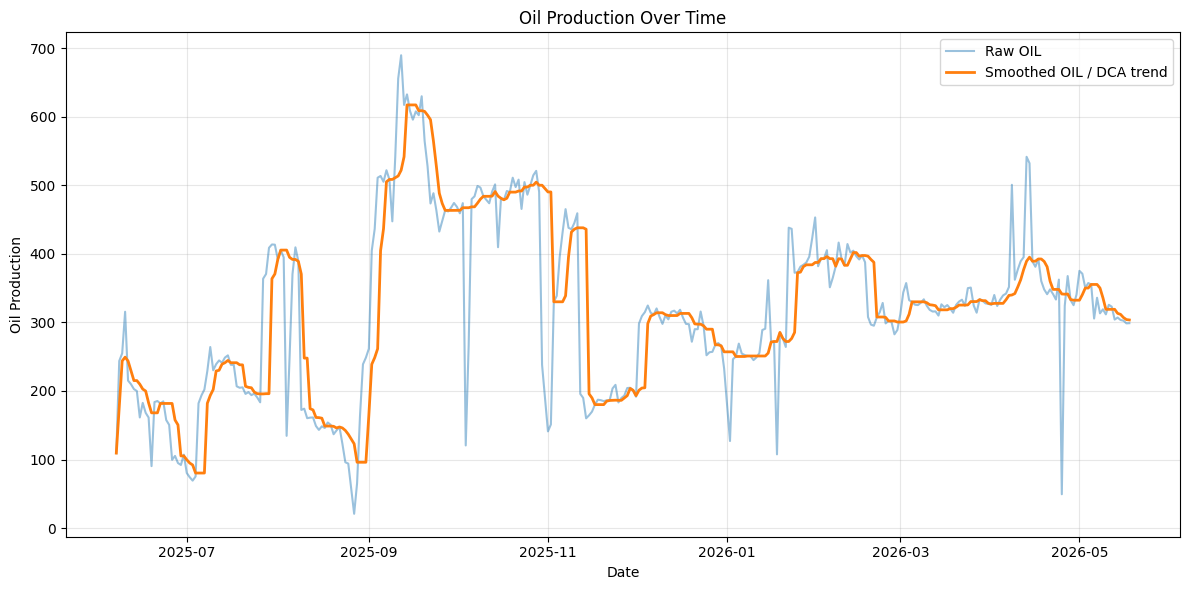

Saved feature dataset to: /home/rian/python_project/myvenv/dca_ml/data/rf03_ln_nonrecursive_feature_dataset.csv
Feature matrix shape: (311, 27)
Target shape        : (311,)
Random Forest training completed.

Non-recursive test performance evaluated on OIL scale
Test OIL MAE : 9.8639
Test OIL MSE : 152.8121
Test OIL RMSE: 12.3617
Test OIL R2  : 0.7059
Saved non-recursive test predictions to: /home/rian/python_project/myvenv/dca_ml/data/rf03_ln_nonrecursive_test_predictions.csv


In [ ]:
def main():
    path = "/home/rian/python_project/myvenv/dca_ml/data/test_data.csv"
    df = load_data(path)

    output_dir = "/home/rian/python_project/myvenv/dca_ml/data"
    os.makedirs(output_dir, exist_ok=True)

    visualize_data(df, save_path=os.path.join(output_dir, "rf03_ln_nonrecursive_raw_vs_smooth.png"))

    minimum_history = 30
    forecast_horizon = 1000
    X_all, y_all, target_indices, model_df = create_dataset(df, minimum_history=minimum_history)

    dataset_out = X_all.copy()
    dataset_out["LN_OIL_TARGET"] = y_all
    dataset_out["TEST_DATE"] = model_df["TEST_DATE"].iloc[target_indices].to_numpy()
    dataset_out["NEXT_TEST_DATE"] = model_df["NEXT_TEST_DATE"].iloc[target_indices].to_numpy()
    dataset_out["OIL_SMOOTH"] = model_df["OIL_SMOOTH"].iloc[target_indices].to_numpy()
    dataset_out["OIL_NEXT"] = model_df["OIL_NEXT"].iloc[target_indices].to_numpy()
    dataset_out["DELTA_T"] = model_df["DELTA_T"].iloc[target_indices].to_numpy()

    dataset_path = os.path.join(output_dir, "rf03_ln_nonrecursive_feature_dataset.csv")
    dataset_out.to_csv(dataset_path, index=False)

    print(f"Saved feature dataset to: {dataset_path}")
    print(f"Feature matrix shape: {X_all.shape}")
    print(f"Target shape        : {y_all.shape}")

    # Chronological train/test split, same general style as rf03.
    train_size = int(len(model_df) * 0.8)
    train_mask = target_indices < train_size
    test_mask = ~train_mask

    X_train, y_train = X_all.loc[train_mask], y_all[train_mask]
    X_test, y_test = X_all.loc[test_mask], y_all[test_mask]
    test_target_indices = target_indices[test_mask]

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features=0.8,
        random_state=42,
        n_jobs=1,
    )
    model.fit(X_train, y_train)
    print("Random Forest training completed.")

    # NON-RECURSIVE test prediction:
    # Each X_test row was built from actual historical oil only.
    # Predicted oil is NOT appended back into history.
    predicted_ln_oil = model.predict(X_test)
    predicted_test_oil = np.exp(predicted_ln_oil)
    predicted_test_oil = np.clip(predicted_test_oil, 1e-6, None)

    actual_test_oil = model_df["OIL_NEXT"].iloc[test_target_indices].to_numpy()
    test_dates = model_df["NEXT_TEST_DATE"].iloc[test_target_indices].to_numpy()

    test_mse = mean_squared_error(actual_test_oil, predicted_test_oil)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(actual_test_oil, predicted_test_oil)
    test_r2 = r2_score(actual_test_oil, predicted_test_oil)

    print("\nNon-recursive test performance evaluated on OIL scale")
    print(f"Test OIL MAE : {test_mae:.4f}")
    print(f"Test OIL MSE : {test_mse:.4f}")
    print(f"Test OIL RMSE: {test_rmse:.4f}")
    print(f"Test OIL R2  : {test_r2:.4f}")

    prediction_df = pd.DataFrame({
        "TEST_DATE": model_df["TEST_DATE"].iloc[test_target_indices].to_numpy(),
        "NEXT_TEST_DATE": test_dates,
        "PREDICTED_LN_OIL_NEXT": predicted_ln_oil,
        "PREDICTED_OIL_NEXT": predicted_test_oil,
        "ACTUAL_OIL_NEXT": actual_test_oil,
    })

    prediction_path = os.path.join(output_dir, "rf03_ln_nonrecursive_test_predictions.csv")
    prediction_df.to_csv(prediction_path, index=False)
    print(f"Saved non-recursive test predictions to: {prediction_path}")

    # Future forecast horizon in steps (recursive roll-forward for future dates only).
    q_future_history = model_df["OIL_SMOOTH"].to_numpy(dtype=float).tolist()
    current_date = model_df["TEST_DATE"].iloc[-1]
    future_dates = []
    future_ln = []
    future_oil = []

    for step in range(forecast_horizon):
        X_future = pd.DataFrame([build_features(q_future_history, len(q_future_history) - 1)])
        X_future = X_future[X_all.columns]

        pred_ln = float(model.predict(X_future)[0])
        pred_oil = float(np.exp(pred_ln))
        pred_oil = max(pred_oil, 1e-6)

        next_date = current_date + pd.Timedelta(days=1)
        future_dates.append(next_date)
        future_ln.append(pred_ln)
        future_oil.append(pred_oil)

        q_future_history.append(pred_oil)
        current_date = next_date

    future_df = pd.DataFrame({
        "STEP": np.arange(1, forecast_horizon + 1),
        "TEST_DATE": future_dates,
        "PREDICTED_LN_OIL_NEXT": future_ln,
        "PREDICTED_OIL_NEXT": future_oil,
    })

    future_path = os.path.join(output_dir, "rf03_ln_nonrecursive_future_1000_steps.csv")
    future_df.to_csv(future_path, index=False)
    print(f"Saved {forecast_horizon}-step future forecast to: {future_path}")
    print("\nFirst 10 rows of future forecast")
    print(future_df.head(10))

    one_step_df = future_df.head(1).copy()
    one_step_path = os.path.join(output_dir, "rf03_ln_nonrecursive_one_step_future.csv")
    one_step_df.to_csv(one_step_path, index=False)
    print(f"Saved one-step future prediction to: {one_step_path}")

    one_step_date = one_step_df["TEST_DATE"].iloc[0]
    one_step_oil = float(one_step_df["PREDICTED_OIL_NEXT"].iloc[0])

    plt.figure(figsize=(14, 7))
    plt.plot(model_df["TEST_DATE"], model_df["OIL"], label="Raw OIL", linewidth=1.5, alpha=0.35)
    plt.plot(model_df["TEST_DATE"], model_df["OIL_SMOOTH"], label="Smoothed OIL / DCA trend", linewidth=2.5)
    plt.plot(test_dates, actual_test_oil, label="Actual next smoothed OIL - test", linewidth=2)
    plt.plot(test_dates, predicted_test_oil, label="Non-recursive predicted next OIL - test", linewidth=2, linestyle="--")
    plt.plot(future_df["TEST_DATE"], future_df["PREDICTED_OIL_NEXT"], label=f"Future forecast ({forecast_horizon} steps)", linewidth=2, linestyle="--")
    plt.scatter(one_step_date, one_step_oil, label="One-step future prediction", s=80)
    plt.axvline(model_df["TEST_DATE"].iloc[train_size], linestyle=":", label="Test start")
    plt.title("Non-recursive Random Forest Prediction - Target ln(OIL_NEXT)")
    plt.xlabel("Date")
    plt.ylabel("OIL")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plot_path = os.path.join(output_dir, "rf03_ln_nonrecursive_prediction.png")
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to: {plot_path}")

    print("\nImportant note:")
    print("Test-period evaluation above is non-recursive because each test row uses actual historical features.")
    print("The saved future horizon uses recursive roll-forward (predictions are fed back as features).")

    return {
        "model": model,
        "X_all": X_all,
        "y_all": y_all,
        "model_df": model_df,
        "prediction_df": prediction_df,
        "future_df": future_df,
        "one_step_df": one_step_df,
    }


if __name__ == "__main__":
    main()
